## Evaluate DASM+Thrifty on test data by obtaining log-likelihoods on (x,y,t)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm import tqdm

from peint.data.datasets.dasm import filter_valid_pcps

from netam import pretrained
from netam.framework import load_crepe
from netam.sequences import assert_pcp_valid, AA_STR_SORTED, AA_PADDING_TOKEN
from netam.dasm import DASMBurrito, DASMDataset
from netam.codon_table import CODON_AA_INDICATOR_MATRIX
from netam.framework import load_pcp_df, add_shm_model_outputs_to_pcp_df

### Prepare dataset in pcp_df format for evaluation with proper branch lengths suitable for DASM

In [3]:
data_dir = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/raw")

heavy = pd.read_csv(data_dir / 'wyatt-10x-1p5m_paired-igh_fs-all_pcp_2024-11-21.csv.gz', compression='gzip', index_col=0)
kappa = pd.read_csv(data_dir / 'wyatt-10x-1p5m_paired-igk_fs-all_pcp_2024-11-21.csv.gz', compression='gzip', index_col=0)
lambd = pd.read_csv(data_dir / 'wyatt-10x-1p5m_paired-igl_fs-all_pcp_2024-11-21.csv.gz', compression='gzip', index_col=0)

heavy['family'] = heavy['sample_id'] + '_' + heavy['family'].astype(str)
kappa['family'] = kappa['sample_id'] + '_' + kappa['family'].astype(str)
lambd['family'] = lambd['sample_id'] + '_' + lambd['family'].astype(str)

heavy['edge_id'] = heavy['family'] + ';' + heavy['parent_name'] + ';' + heavy['child_name']
kappa['edge_id'] = kappa['family'] + ';' + kappa['parent_name'] + ';' + kappa['child_name']
lambd['edge_id'] = lambd['family'] + ';' + lambd['parent_name'] + ';' + lambd['child_name']

In [4]:
keep_kappa = (kappa.edge_id.isin(heavy.edge_id)) & ~(kappa.edge_id.isin(lambd.edge_id))
keep_lambd = (lambd.edge_id.isin(heavy.edge_id)) & ~(lambd.edge_id.isin(kappa.edge_id))
kappa = kappa[keep_kappa]
lambd = lambd[keep_lambd]
keep_heavy = (heavy.edge_id.isin(kappa.edge_id)) | (heavy.edge_id.isin(lambd.edge_id))
heavy = heavy[keep_heavy]

In [5]:
merge_cols = ['sample_id', 'family', 'parent_name', 'child_name', 'edge_id']
keep_cols = ['parent', 'child', 'branch_length', 'depth', 'distance', 'v_gene', 'cdr1_codon_start', 
             'cdr1_codon_end', 'cdr2_codon_start', 'cdr2_codon_end', 'cdr3_codon_start', 'cdr3_codon_end',
             'parent_is_naive', 'child_is_leaf']
keep_cols = merge_cols + keep_cols

In [6]:
heavy_kappa = pd.merge(heavy[keep_cols], kappa[keep_cols], on=merge_cols, how='inner', suffixes=('_heavy', '_light'))
heavy_lambd = pd.merge(heavy[keep_cols], lambd[keep_cols], on=merge_cols, how='inner', suffixes=('_heavy', '_light'))
full_df = pd.concat([heavy_kappa, heavy_lambd], axis=0)

In [7]:
full_df = full_df[full_df['sample_id'] == 'd4']
full_df = full_df[['parent_heavy', 'parent_light', 'child_heavy', 'child_light', 'branch_length_heavy']]
full_df.rename(columns={'branch_length_heavy': 'branch_length'}, inplace=True)
full_df = full_df[(full_df.parent_heavy != full_df.child_heavy) | (full_df.parent_light != full_df.child_light)]
print(full_df.shape)

(62972, 5)


In [8]:
full_df = filter_valid_pcps(full_df)
print(full_df.shape)

Filtering PCPs without mutations, or whose ambiguities make them unusable for inference


 98%|█████████▊| 6193/6298 [00:18<00:00, 571.94it/s]

(62964, 5)


100%|██████████| 6298/6298 [00:19<00:00, 330.52it/s]


In [10]:
# save this processed df to disk
full_df.to_csv("/accounts/projects/yss/stephen.lu/peint/data/wyatt/subs/dasm_eval_d4.csv.gz", compression='gzip', index=False)

### Now we are ready to infer transition likelihoods using DASM+Thrifty

In [11]:
DASM_TRAINED_MODELS_DIR = "/scratch/users/stephen.lu/projects/dasm/dasm-train/trained_models"
MODEL_NAME = "dasm_4m-v1tangCC+v1vanwinkleheavyTrainCC+v1jaffePairedCC+v1vanwinklelightTrainCC1m-joint"
crepe = pretrained.load_crepe(f"{DASM_TRAINED_MODELS_DIR}/{MODEL_NAME}")

In [12]:
model = crepe.model
model_known_token_count = model.hyperparameters["known_token_count"]
neutral_model_name = model.hyperparameters["neutral_model_name"]
multihit_model_name = model.hyperparameters["multihit_model_name"]

In [ ]:
neutral_crepe = pretrained.load(neutral_model_name, device="cuda")
pcp_df = add_shm_model_outputs_to_pcp_df(full_df, neutral_crepe)

Loading model ThriftyHumV0.2-59
Using cached models: /accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/netam/_pretrained/thrifty-0.2.0.zip


Evaluating model: 100%|██████████| 6297/6297 [00:21<00:00, 297.90it/s]


In [14]:
full_df["in_train"] = False
_, dataset = DASMDataset.train_val_datasets_of_pcp_df(
    pcp_df=full_df,
    model_known_token_count=model_known_token_count,
    branch_length_multiplier=5.0,
    multihit_model=pretrained.load_multihit(multihit_model_name, device="cuda"),
)

Loading multihit model ThriftyHumV0.2-59-hc-tangshm


In [15]:
burrito = DASMBurrito(
    train_dataset=None,
    val_dataset=dataset,
    model=model,
    optimizer_name="RMSprop",
    batch_size=1024,
    learning_rate=0.001,
    min_learning_rate=1e-6,
    weight_decay=1e-6,
)

### Begin by making predictions using the optimized branch lengths that the model itself chooses

In [16]:
original_branch_lengths = full_df.branch_length.values

In [17]:
burrito.standardize_and_optimize_branch_lengths()
burrito.val_dataset.update_neutral_probs()
optimized_branch_lengths = burrito.val_dataset.branch_lengths

Finding optimal branch lengths: 100%|██████████| 6296/6296 [07:02<00:00, 14.91it/s]


In [48]:
hv_sizes = full_df.nt_rates_heavy.apply(lambda x: x.shape.numel() // 3).values
lt_sizes = full_df.nt_rates_light.apply(lambda x: x.shape.numel() // 3).values

In [68]:
full_df.head()

,parent_heavy,parent_light,child_heavy,child_light,branch_length,nt_rates_heavy,nt_csps_heavy,nt_csps_light,nt_rates_light,in_train
16,CAGGTGCAGCTGGTGGAGTCTGGGGGAGGCGTGGTCCAGCCTGGGA...,GAAATTGTGTTGACGCAGTCTCCAGGCACCCTGTCTTTGTCTCCAG...,CAGGTGCAGCTGGTGGAGTCTGGGGGAGGCGTGGTCCAGCCTGGGA...,GAAATTGTGTTGACGCAGTCTCCAGGTAGCCTGTCTTTGTCTCCAG...,0.040899,"[tensor(0.3117), tensor(0.4563), tensor(0.7344...","[[tensor(0.2338), tensor(0.), tensor(0.3031), ...","[[tensor(0.2016), tensor(0.3990), tensor(0.), ...","[tensor(0.5745), tensor(0.6018), tensor(1.1335...",False
43,GAGGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,GATATTGTGATGACTCAGTCTCCACTCTCCCTGCCCGTCACCCCTG...,GAGGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,GATATTGTGATGACTCAGTCTCCACTCTCCCTGCCCGTCACCCCTG...,0.039968,"[tensor(0.4659), tensor(0.6480), tensor(1.1762...","[[tensor(0.1922), tensor(0.4680), tensor(0.), ...","[[tensor(0.2021), tensor(0.4678), tensor(0.), ...","[tensor(0.8881), tensor(1.1159), tensor(1.3595...",False
44,GAGGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,GATATTGTGATGACTCAGTCTCCACTCTCCCTGCCCGTCACCCCTG...,GAGGTGCAACTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,GATATTGTGATGACTCAGTCTCCACTCTCCCTGCCCGTCACCCCTG...,0.024386,"[tensor(0.4659), tensor(0.6480), tensor(1.1762...","[[tensor(0.1922), tensor(0.4680), tensor(0.), ...","[[tensor(0.2021), tensor(0.4678), tensor(0.), ...","[tensor(0.8881), tensor(1.1159), tensor(1.3595...",False
45,GAGGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,GATATTGTGATGACTCAGTCTCCACTCTCCCTGCCCGTCACCCCTG...,GAGGTGCAGCTGGTGGAATCTGGGGGAGGCTTGGTCCAGCCTGGGG...,GATATTGTGATGACTCAGTCTCCACTCTCCCTGCCCGTCACCCCTG...,0.016900,"[tensor(0.4659), tensor(0.6480), tensor(1.1762...","[[tensor(0.1922), tensor(0.4680), tensor(0.), ...","[[tensor(0.2021), tensor(0.4678), tensor(0.), ...","[tensor(0.8881), tensor(1.1159), tensor(1.3595...",False
73,GAGGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,GATATTGTGATGACTCAGTCTCCACTCTCCCTGCCCGTCACCCCTG...,GAGGTGCAATTGGTGGAGTCTGGGGGAGACTTGGTCCAGCCGGGGG...,GATATTGTGGTGACTCAGTCTCCCCTCTCCCTGCCCGTCACCCCTG...,0.084183,"[tensor(0.4659), tensor(0.6480), tensor(1.1762...","[[tensor(0.1922), tensor(0.4680), tensor(0.), ...","[[tensor(0.2021), tensor(0.4678), tensor(0.), ...","[tensor(0.8881), tensor(1.1159), tensor(1.3595...",False


In [73]:
burrito.model.eval()
burrito.model = burrito.model.cuda()
val_loader = burrito.build_val_loader()

lls, ppl = [], []
all_hv_szs, all_lt_szs = [], []
all_hv_nlls, all_lt_nlls = [], []

for idx, batch in enumerate(tqdm(val_loader, desc="Calculating model predictions")):
    batch = {k: v.cuda() for k, v in batch.items()}
    log_preds = burrito.predictions_of_batch(batch).detach().cpu()

    max_log_preds = log_preds.max(dim=-1, keepdim=True).values
    aa_probs = torch.exp(log_preds - max_log_preds) @ CODON_AA_INDICATOR_MATRIX
    aa_log_preds = torch.log(aa_probs + 1e-10) + max_log_preds

    aa_tgt = batch['aa_children_idxs'].cpu().detach()
    
    # find the position of the first aa_tgt == 21 for each sequence in the batch
    # also find the position of the first aa_tgt == 20 padding token for each sequence in the batch
    # sep_token_idx = (aa_tgt == 21).float().argmax(dim=-1)
    # pad_token_idx = (aa_tgt == AA_PADDING_TOKEN).float().argmax(dim=-1)
    # assert all(sep_token_idx < pad_token_idx)
    
    # calculate the length of the heavy and light chains for each sequence in batch
    # heavy chain is from 0 to sep_token_idx[i], light chain is from sep_token_idx[i] + 1 to pad_token_idx[i]
    y_hv_sz = hv_sizes[idx * burrito.batch_size:(idx + 1) * burrito.batch_size]
    y_lt_sz = lt_sizes[idx * burrito.batch_size:(idx + 1) * burrito.batch_size]

    # replace values in aa_tgt == 21 with 20
    aa_tgt[aa_tgt == 21] = 20

    # Keep unreduced to get per-site time likelihood (B, L)
    nll = F.cross_entropy(
        aa_log_preds.transpose(-1, -2),
        aa_tgt,
        ignore_index=AA_PADDING_TOKEN,
        reduction="none",
    ).detach()

    # separate nlls by heavy chain and light chain
    nll = nll.detach().cpu().numpy()
    hv_nlls = [nll[i, :L] for i, L in enumerate(y_hv_sz)]
    lt_nlls = [nll[i, L+1:L+1+y_lt_sz[i]] for i, L in enumerate(y_hv_sz)]
    assert all([len(hvll) == hvc for hvll, hvc in zip(hv_nlls, y_hv_sz)])
    assert all([len(ltll) == ltc for ltll, ltc in zip(lt_nlls, y_lt_sz)])

    all_hv_nlls.extend(hv_nlls)
    all_lt_nlls.extend(lt_nlls)
    all_hv_szs.append(y_hv_sz)
    all_lt_szs.append(y_lt_sz)

    # compute perplexity
    # padding_mask = aa_tgt != AA_PADDING_TOKEN
    # ll = -nll * padding_mask.float()
    # ll = ll.sum(dim=-1)
    # lls.append(ll.detach().cpu().numpy())
    # nll_mean = (nll * padding_mask.float()).sum(dim=-1) / padding_mask.float().sum(dim=-1)
    # ppl.append(torch.exp(nll_mean).detach().cpu().numpy())

# lls = np.concatenate(lls)
# ppl = np.concatenate(ppl)
bls = optimized_branch_lengths.numpy()

Calculating model predictions: 100%|██████████████████████████████████████████████████████| 62/62 [00:19<00:00,  3.10it/s]


In [74]:
# pad the nlls to the same length
from evo.tensor import collate_tensors
hv_nlls_padded = collate_tensors(all_hv_nlls, constant_value=0.0)
lt_nlls_padded = collate_tensors(all_lt_nlls, constant_value=0.0)
hv_szs = np.concatenate(all_hv_szs)
lt_szs = np.concatenate(all_lt_szs)

In [75]:
# combine these numpy arrays into a numpy structured array and save to disk
save_path = "/accounts/projects/yss/stephen.lu/peint/results/inf_eval"
np.savez(f"{save_path}/dasm_nlls_d4.npz", hv_nlls=hv_nlls_padded, lt_nlls=lt_nlls_padded, hv_szs=hv_szs, lt_szs=lt_szs, bls=bls)

In [89]:
print('test perplexity: ', np.nanmean(ppl))

# save branch, lls, and ppls to a dataframe
df = pd.DataFrame({
    "dasm_branch": bls,
    "orig_branch": original_branch_lengths,
    "log_likelihood": lls,
    "perplexity": ppl,
})

df.to_csv("results/inf_eval/dasm_d4.csv", index=False)

test perplexity:  1.2249851


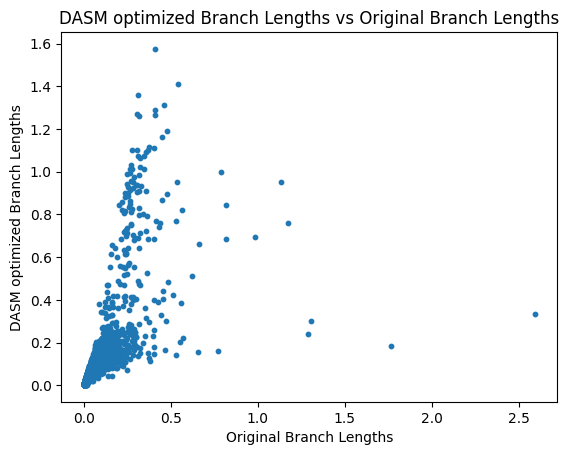

In [88]:
# scatter plot bls versus original_branch_lengths
fig, ax = plt.subplots()
ax.scatter(original_branch_lengths, bls, s=10)
ax.set_xlabel("Original Branch Lengths")
ax.set_ylabel("DASM optimized Branch Lengths")
ax.set_title("DASM optimized Branch Lengths vs Original Branch Lengths")
plt.show()

### Begin by making predictions using the original branch lengths in the dataset

In [116]:
original_branch_lengths = full_df.branch_length.values
burrito.val_dataset.branch_lengths = torch.Tensor(original_branch_lengths)
burrito.val_dataset.update_neutral_probs()

In [121]:
burrito.model.eval()
burrito.model = burrito.model.cuda()
val_loader = burrito.build_val_loader()
lls, ppl = [], []

for batch in tqdm(val_loader, desc="Calculating model predictions"):
    batch = {k: v.cuda() for k, v in batch.items()}
    log_preds = burrito.predictions_of_batch(batch).detach().cpu()

    max_log_preds = log_preds.max(dim=-1, keepdim=True).values
    aa_probs = torch.exp(log_preds - max_log_preds) @ CODON_AA_INDICATOR_MATRIX
    aa_log_preds = torch.log(aa_probs + 1e-10) + max_log_preds

    aa_tgt = batch['aa_children_idxs'].cpu().detach()
    
    # replace values in aa_tgt == 21 with 20
    aa_tgt[aa_tgt == 21] = 20

    # Keep unreduced to get per-site time likelihood (B, L)
    nll = F.cross_entropy(
        aa_log_preds.transpose(-1, -2),
        aa_tgt,
        ignore_index=AA_PADDING_TOKEN,
        reduction="none",
    ).detach()

    # compute perplexity
    padding_mask = aa_tgt != AA_PADDING_TOKEN
    ll = -nll * padding_mask.float()
    ll = ll.sum(dim=-1)
    lls.append(ll.detach().cpu().numpy())
    nll_mean = (nll * padding_mask.float()).sum(dim=-1) / padding_mask.float().sum(dim=-1)
    ppl.append(torch.exp(nll_mean).detach().cpu().numpy())

lls = np.concatenate(lls)
ppl = np.concatenate(ppl)
bls = original_branch_lengths

Calculating model predictions: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37/37 [00:16<00:00,  2.26it/s]


In [122]:
print('test perplexity: ', np.nanmean(ppl))

# save branch, lls, and ppls to a dataframe
df = pd.DataFrame({
    "dasm_branch": bls,
    "orig_branch": original_branch_lengths,
    "log_likelihood": lls,
    "perplexity": ppl,
})

df.to_csv("results/inf_eval/dasm_orig_bls_dx.csv", index=False)

test perplexity:  1.1689852
